In [ ]:
# ============================================
# Portugal Renewable Energy Analysis
# Author: Marius Faur
# Context: EDP Asset Management Interview
# Tools: Python, Pandas, Matplotlib, Seaborn
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Upload do ficheiro
from google.colab import files
uploaded = files.upload()

# Carregar o dataset — ajusta o nome do ficheiro se necessário
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

# Primeira exploração
print(f"Shape: {df.shape}")
print(f"\nColunas:\n{df.columns.tolist()}")
print(f"\nPrimeiras linhas:")
df.head(10)

Saving electricity-prod-source-stacked.csv to electricity-prod-source-stacked.csv
Shape: (6714, 12)

Colunas:
['Entity', 'Code', 'Year', 'Other renewables', 'Bioenergy', 'Solar', 'Wind', 'Hydropower', 'Nuclear', 'Oil', 'Gas', 'Coal']

Primeiras linhas:


,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal
0,ASEAN (Ember),NaN,2000,16.93,5.87,0.00,0.00,50.45,0.0,65.07,164.26,76.03
1,ASEAN (Ember),NaN,2001,16.40,6.46,0.00,0.00,54.33,0.0,50.99,190.41,86.26
2,ASEAN (Ember),NaN,2002,16.61,6.62,0.00,0.00,53.29,0.0,54.32,208.92,93.43
3,ASEAN (Ember),NaN,2003,15.74,7.45,0.00,0.00,53.21,0.0,53.38,226.51,102.01
4,ASEAN (Ember),NaN,2004,16.57,8.40,0.00,0.00,52.99,0.0,59.50,244.16,115.01
5,ASEAN (Ember),NaN,2005,16.50,8.80,0.00,0.02,53.88,0.0,65.72,253.30,124.53
6,ASEAN (Ember),NaN,2006,17.13,8.53,0.04,0.05,60.52,0.0,60.24,262.67,138.08
7,ASEAN (Ember),NaN,2007,17.24,10.25,0.04,0.06,63.25,0.0,58.57,274.02,155.70
8,ASEAN (Ember),NaN,2008,19.03,10.55,0.04,0.06,69.94,0.0,59.24,293.09,152.01
9,ASEAN (Ember),NaN,2009,19.62,10.88,0.04,0.07,73.68,0.0,48.69,308.82,162.79


In [ ]:
# Filtrar apenas Portugal
pt = df[df['Entity'] == 'Portugal'].copy()
pt = pt.sort_values('Year').reset_index(drop=True)

# Ver o que temos
print(f"Portugal data: {pt.shape}")
print(f"Years: {pt['Year'].min()} to {pt['Year'].max()}")
print(f"\nMissing values:\n{pt.isnull().sum()}")
pt.head(10)

Portugal data: (36, 12)
Years: 1990 to 2025

Missing values:
Entity              0
Code                0
Year                0
Other renewables    0
Bioenergy           0
Solar               0
Wind                0
Hydropower          0
Nuclear             0
Oil                 0
Gas                 0
Coal                0
dtype: int64


,Entity,Code,Year,Other renewables,Bioenergy,Solar,Wind,Hydropower,Nuclear,Oil,Gas,Coal
0,Portugal,PRT,1990,0.00,0.69,0.0,0.00,9.14,0.0,9.44,0.00,9.06
1,Portugal,PRT,1991,0.00,0.81,0.0,0.00,9.03,0.0,10.13,0.00,9.75
2,Portugal,PRT,1992,0.00,0.88,0.0,0.00,4.61,0.0,13.82,0.00,10.17
3,Portugal,PRT,1993,0.00,0.90,0.0,0.01,8.52,0.0,10.03,0.00,11.38
4,Portugal,PRT,1994,0.03,0.93,0.0,0.02,10.65,0.0,7.92,0.00,11.57
5,Portugal,PRT,1995,0.04,0.99,0.0,0.02,8.33,0.0,10.12,0.00,13.41
6,Portugal,PRT,1996,0.05,0.96,0.0,0.02,14.75,0.0,5.87,0.00,12.55
7,Portugal,PRT,1997,0.05,1.04,0.0,0.04,13.10,0.0,6.61,0.09,12.96
8,Portugal,PRT,1998,0.06,1.02,0.0,0.09,12.98,0.0,10.60,2.02,11.98
9,Portugal,PRT,1999,0.08,1.16,0.0,0.12,7.26,0.0,11.00,8.07,15.05


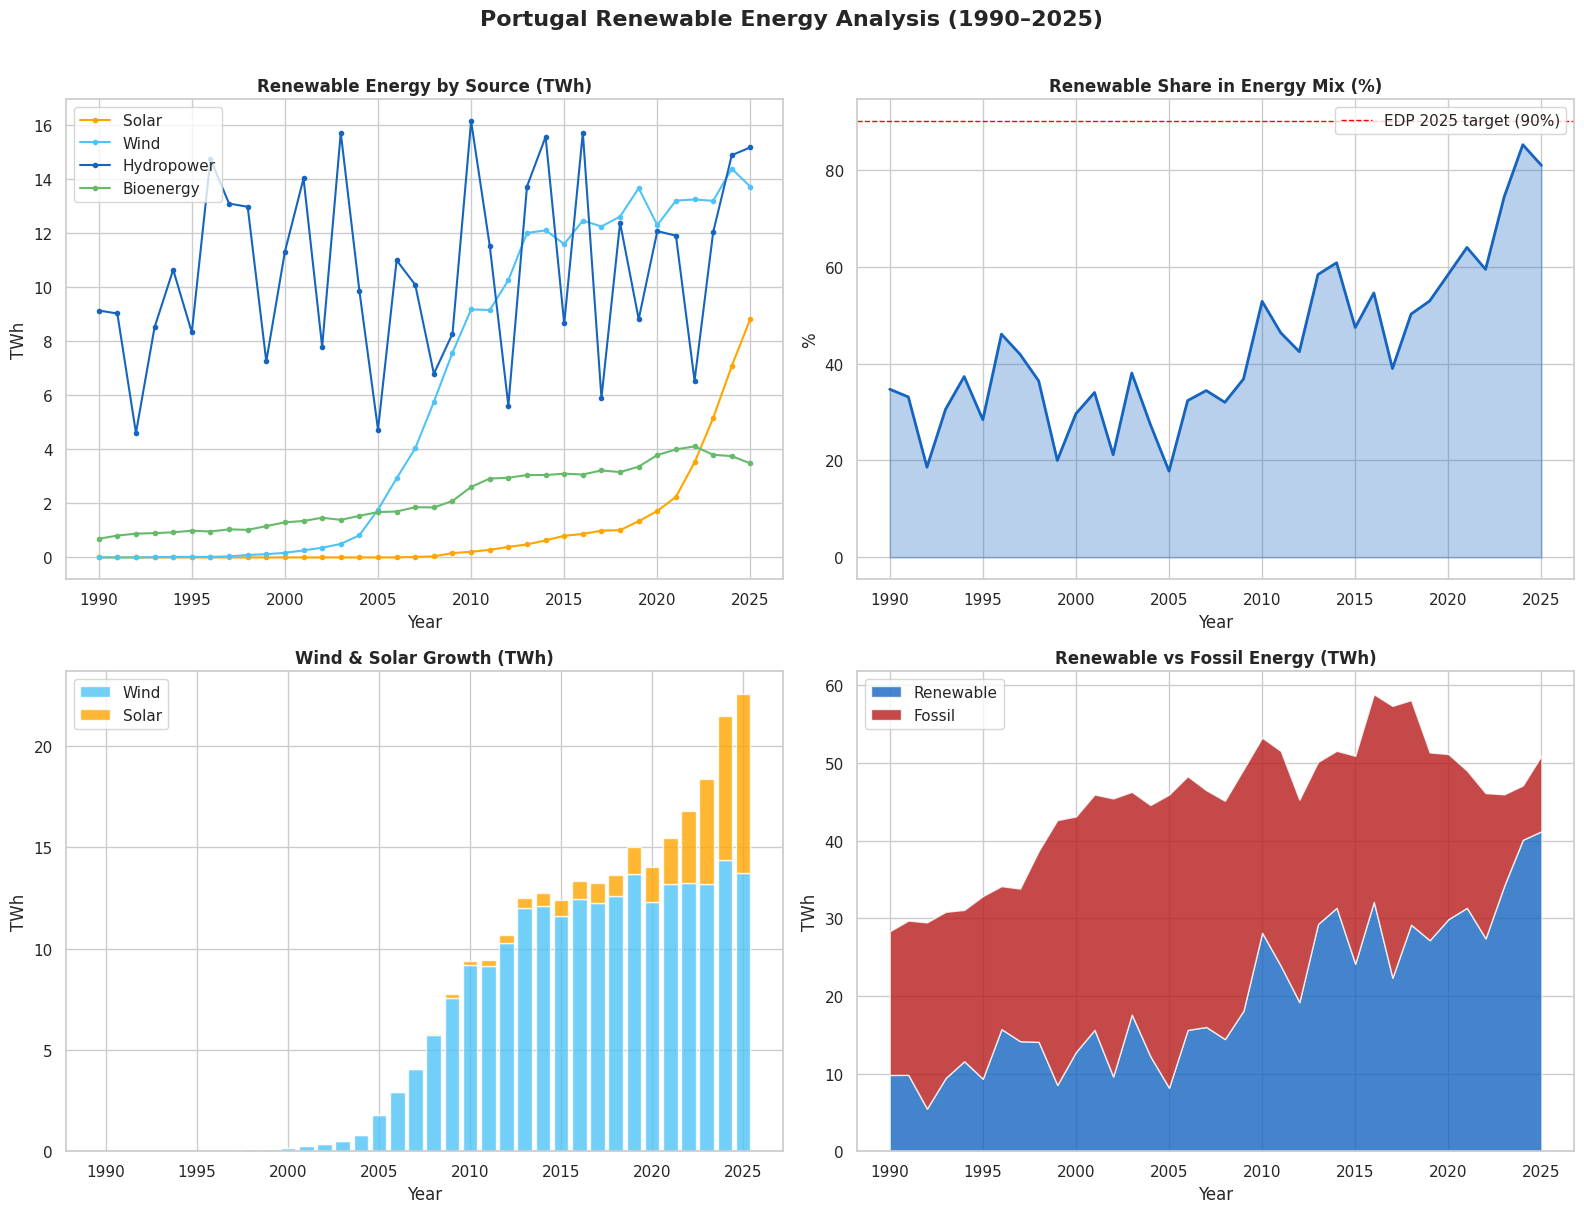

Saved!


In [ ]:
# Evolução da produção renovável em Portugal
renewable_cols = ['Solar', 'Wind', 'Hydropower', 'Bioenergy']
fossil_cols = ['Oil', 'Gas', 'Coal']

# Calcular total renovável e fóssil
pt['Total_Renewable'] = pt[renewable_cols].sum(axis=1)
pt['Total_Fossil'] = pt[fossil_cols].sum(axis=1)
pt['Total'] = pt['Total_Renewable'] + pt['Total_Fossil']
pt['Renewable_Pct'] = (pt['Total_Renewable'] / pt['Total']) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Portugal Renewable Energy Analysis (1990–2025)',
             fontsize=16, fontweight='bold', y=1.01)

# Gráfico 1 — Evolução por fonte renovável
ax1 = axes[0, 0]
for col, color in zip(['Solar', 'Wind', 'Hydropower', 'Bioenergy'],
                       ['#FFA500', '#4FC3F7', '#1565C0', '#66BB6A']):
    ax1.plot(pt['Year'], pt[col], marker='o', markersize=3, label=col, color=color)
ax1.set_title('Renewable Energy by Source (TWh)', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('TWh')
ax1.legend()

# Gráfico 2 — % Renovável no mix energético
ax2 = axes[0, 1]
ax2.fill_between(pt['Year'], pt['Renewable_Pct'], alpha=0.3, color='#1565C0')
ax2.plot(pt['Year'], pt['Renewable_Pct'], color='#1565C0', linewidth=2)
ax2.axhline(y=90, color='red', linestyle='--', linewidth=1, label='EDP 2025 target (90%)')
ax2.set_title('Renewable Share in Energy Mix (%)', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('%')
ax2.legend()

# Gráfico 3 — Solar vs Wind crescimento
ax3 = axes[1, 0]
ax3.bar(pt['Year'], pt['Wind'], label='Wind', color='#4FC3F7', alpha=0.8)
ax3.bar(pt['Year'], pt['Solar'], bottom=pt['Wind'], label='Solar', color='#FFA500', alpha=0.8)
ax3.set_title('Wind & Solar Growth (TWh)', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('TWh')
ax3.legend()

# Gráfico 4 — Renovável vs Fóssil
ax4 = axes[1, 1]
ax4.stackplot(pt['Year'], pt['Total_Renewable'], pt['Total_Fossil'],
              labels=['Renewable', 'Fossil'],
              colors=['#1565C0', '#B71C1C'], alpha=0.8)
ax4.set_title('Renewable vs Fossil Energy (TWh)', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('TWh')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.savefig('portugal_energy_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved!")

In [ ]:
# Key insights para a entrevista
print("=" * 55)
print("KEY INSIGHTS — Portugal Renewable Energy (1990–2025)")
print("=" * 55)

# Solar growth
solar_2010 = pt[pt['Year']==2010]['Solar'].values[0]
solar_2025 = pt[pt['Year']==2025]['Solar'].values[0]
print(f"\nSolar Energy:")
print(f"  2010: {solar_2010:.2f} TWh → 2025: {solar_2025:.2f} TWh")
print(f"  Growth: +{((solar_2025-solar_2010)/solar_2010*100):.0f}%")

# Wind growth
wind_2010 = pt[pt['Year']==2010]['Wind'].values[0]
wind_2025 = pt[pt['Year']==2025]['Wind'].values[0]
print(f"\nWind Energy:")
print(f"  2010: {wind_2010:.2f} TWh → 2025: {wind_2025:.2f} TWh")
print(f"  Growth: +{((wind_2025-wind_2010)/wind_2010*100):.0f}%")

# Renewable share
ren_1990 = pt[pt['Year']==1990]['Renewable_Pct'].values[0]
ren_2025 = pt[pt['Year']==2025]['Renewable_Pct'].values[0]
print(f"\nRenewable Share:")
print(f"  1990: {ren_1990:.1f}% → 2025: {ren_2025:.1f}%")
print(f"  EDP Target 2030: 100%")

# Best renewable year
best_year = pt.loc[pt['Renewable_Pct'].idxmax(), 'Year']
best_pct = pt['Renewable_Pct'].max()
print(f"\nBest renewable year: {best_year} ({best_pct:.1f}%)")

# Fossil reduction
fossil_2010 = pt[pt['Year']==2010]['Total_Fossil'].values[0]
fossil_2025 = pt[pt['Year']==2025]['Total_Fossil'].values[0]
print(f"\nFossil Energy:")
print(f"  2010: {fossil_2010:.2f} TWh → 2025: {fossil_2025:.2f} TWh")
print(f"  Reduction: {((fossil_2025-fossil_2010)/fossil_2010*100):.0f}%")

print("\nAnalysis complete!")

KEY INSIGHTS — Portugal Renewable Energy (1990–2025)

Solar Energy:
  2010: 0.21 TWh → 2025: 8.84 TWh
  Growth: +4110%

Wind Energy:
  2010: 9.18 TWh → 2025: 13.72 TWh
  Growth: +49%

Renewable Share:
  1990: 34.7% → 2025: 80.9%
  EDP Target 2030: 100%

Best renewable year: 2024 (85.1%)

Fossil Energy:
  2010: 25.13 TWh → 2025: 9.74 TWh
  Reduction: -61%

Analysis complete!
